# Demo: Adaptive Bio-Signal DSP Pipeline

A **self-contained, runnable walkthrough** of the pipeline's core algorithms on a synthetic EEG-like signal (no dataset download, no GPU). It imports the real modules from `src/` so what you see here is exactly what the weekly scripts use.

**Covers:** synthetic signal → LMS → RLS (convergence + λ sweep) → Wavelet band-power features → Q15 fixed-point + SQNR → MACs/second.

For the real BCI Competition IV-2a pipeline (CSP, LDA, EEGNet-Lite) see `scripts/` and `docs/USER_GUIDE.md`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root, so `src` is importable

import numpy as np
import matplotlib.pyplot as plt

from src.filters import lms_filter, rls_filter
from src.features import BAND_NAMES, extract_wavelet_features
from src.fixedpoint import float_to_q15, q15_to_float, lms_filter_q15
from src.utils import compute_sqnr, count_macs_lms, count_macs_rls

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (10, 3)

## 1. Synthetic EEG-like signal

Alpha (10 Hz) + beta (20 Hz) rhythms with background noise, 50 Hz powerline interference, and a short motion-artifact burst.

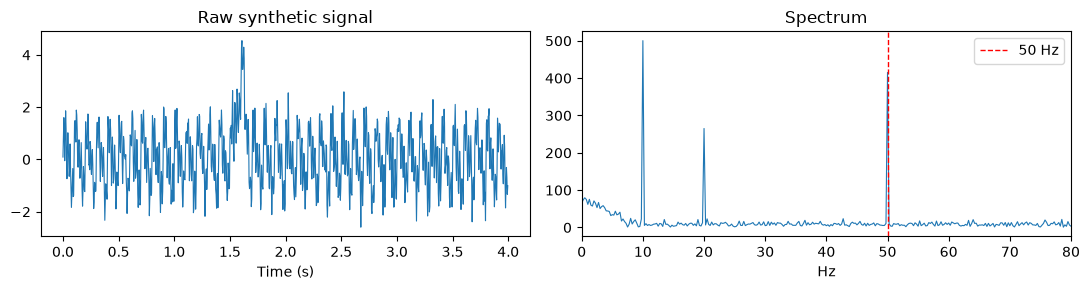

In [2]:
fs, duration = 250, 4.0
n = int(fs * duration)
t = np.arange(n) / fs

neural = 1.0 * np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.3 * rng.standard_normal(n)
powerline = 0.8 * np.sin(2 * np.pi * 50 * t)
artifact = np.zeros(n)
b0, blen = int(1.5 * fs), int(0.2 * fs)
artifact[b0:b0 + blen] = 3.0 * np.hanning(blen)

x = neural + powerline + artifact          # observed noisy channel
ref50 = np.sin(2 * np.pi * 50 * t)         # reference for the adaptive canceller

freqs = np.fft.rfftfreq(n, d=1 / fs)
spec = np.abs(np.fft.rfft(x))

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, x, lw=0.8); ax[0].set_title("Raw synthetic signal"); ax[0].set_xlabel("Time (s)")
ax[1].plot(freqs, spec, lw=0.8); ax[1].axvline(50, c="r", ls="--", lw=1, label="50 Hz")
ax[1].set_xlim(0, 80); ax[1].set_title("Spectrum"); ax[1].set_xlabel("Hz"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. LMS adaptive filter (50 Hz cancellation)

`src.filters.lms_filter(d, x_ref, mu, N)` — O(N) per sample.

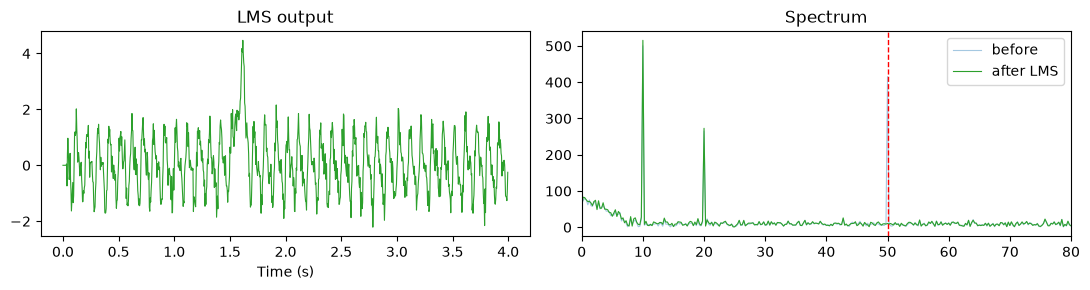

50 Hz magnitude: before = 415.4, after LMS = 10.6


In [3]:
N, mu = 8, 0.02
e_lms, w_lms = lms_filter(x, ref50, mu=mu, N=N)
spec_lms = np.abs(np.fft.rfft(e_lms))

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, e_lms, lw=0.8, c="tab:green"); ax[0].set_title("LMS output"); ax[0].set_xlabel("Time (s)")
ax[1].plot(freqs, spec, lw=0.8, alpha=0.4, label="before"); ax[1].plot(freqs, spec_lms, lw=0.8, c="tab:green", label="after LMS")
ax[1].axvline(50, c="r", ls="--", lw=1); ax[1].set_xlim(0, 80); ax[1].legend(); ax[1].set_title("Spectrum")
plt.tight_layout(); plt.show()

i50 = np.argmin(np.abs(freqs - 50))
print(f"50 Hz magnitude: before = {spec[i50]:.1f}, after LMS = {spec_lms[i50]:.1f}")

## 3. RLS adaptive filter: faster convergence, higher cost

`src.filters.rls_filter(d, x_ref, lam, N)` — O(N²) per sample. The forgetting factor λ must stay close to 1: with a single-tone reference, λ = 0.9 triggers *covariance wind-up* (see `docs/report/week2_rls_vs_lms.md`).

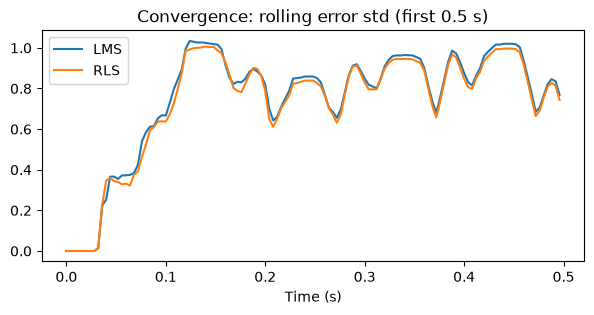

 lambda |  RMS first 10% |  RMS last 10%
   0.90 |         0.8910 |        4.5465
   0.95 |         0.8581 |        3.5866
   0.99 |         0.8368 |        0.8742


   1.00 |         0.8328 |        0.8659


In [4]:
e_rls, w_rls = rls_filter(x, ref50, lam=0.99, N=N)

win = 20
env = lambda e: np.array([np.std(e[max(0, i - win):i + 1]) for i in range(n)])
k = int(0.5 * fs)
plt.figure(figsize=(7, 3))
plt.plot(t[:k], env(e_lms)[:k], label="LMS"); plt.plot(t[:k], env(e_rls)[:k], label="RLS")
plt.title("Convergence: rolling error std (first 0.5 s)"); plt.xlabel("Time (s)"); plt.legend(); plt.show()

print(f"{'lambda':>7} | {'RMS first 10%':>14} | {'RMS last 10%':>13}")
for lam in [0.90, 0.95, 0.99, 1.00]:
    e, _ = rls_filter(x, ref50, lam=lam, N=N)
    m = n // 10
    print(f"{lam:7.2f} | {np.sqrt(np.mean(e[:m]**2)):14.4f} | {np.sqrt(np.mean(e[-m:]**2)):13.4f}")

## 4. Wavelet band-power features

`src.features.extract_wavelet_features` — 5-level `db4` decomposition, log mean energy per sub-band, fixed length of 6 regardless of window size.

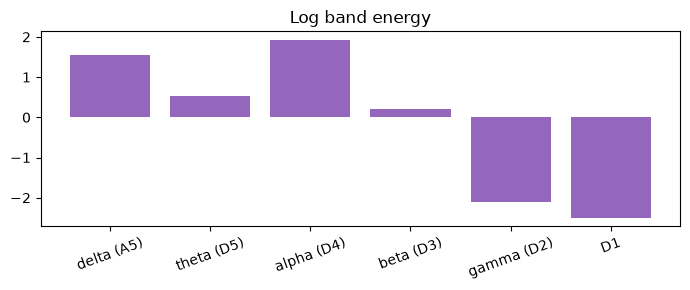

  delta (A5):   1.547
  theta (D5):   0.541
  alpha (D4):   1.917
   beta (D3):   0.195
  gamma (D2):  -2.098
          D1:  -2.492
Feature length for 250-sample window: 6


In [5]:
feat = extract_wavelet_features(e_rls)
plt.figure(figsize=(7, 3))
plt.bar(BAND_NAMES, feat, color="tab:purple"); plt.title("Log band energy"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
for name, v in zip(BAND_NAMES, feat):
    print(f"{name:>12}: {v:7.3f}")
print("Feature length for 250-sample window:", len(extract_wavelet_features(e_rls[:250])))

## 5. Q15 fixed-point LMS and SQNR

`src.fixedpoint.lms_filter_q15` runs the same LMS using only int16/int64 integer arithmetic (Q15 × Q15 → Q30 → `>> 15`). The input **must** be normalised into [−1, 1) first: the cell below shows the SQNR collapse when it is not.

SQNR without normalisation:   6.34 dB
SQNR with normalisation:     54.65 dB   (target >= 30 dB)


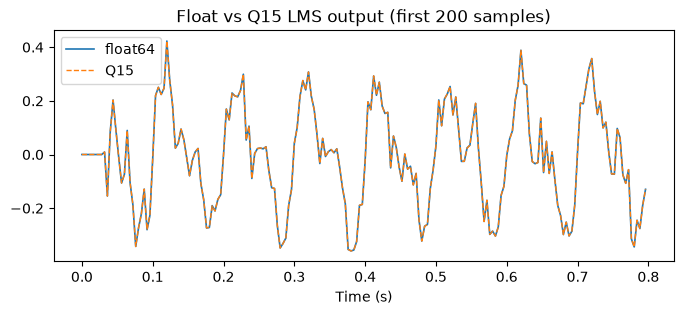

In [6]:
def q15_run(d_in):
    e_q, _ = lms_filter_q15(d_in, ref50, mu_float=mu, N=N)
    e_f, _ = lms_filter(d_in, ref50, mu, N)
    return compute_sqnr(e_f, q15_to_float(e_q)), e_f, q15_to_float(e_q)

sqnr_raw, _, _ = q15_run(x)                                   # unnormalised: saturates
x_norm = x / (np.max(np.abs(x)) * 1.05)                       # 5 % headroom below Q15_MAX
sqnr_norm, e_f, e_q = q15_run(x_norm)

print(f"SQNR without normalisation: {sqnr_raw:6.2f} dB")
print(f"SQNR with normalisation:    {sqnr_norm:6.2f} dB   (target >= 30 dB)")

plt.figure(figsize=(8, 3))
plt.plot(t[:200], e_f[:200], label="float64", lw=1.2); plt.plot(t[:200], e_q[:200], "--", label="Q15", lw=1)
plt.title("Float vs Q15 LMS output (first 200 samples)"); plt.xlabel("Time (s)"); plt.legend(); plt.show()

## 6. MACs/second estimate

Theoretical cost per sample: LMS `2N`, RLS `4N²` (`src.utils.count_macs_*`). Week 6 shows the counted and measured ratios are smaller than this bound (16× → 10× → 4.5–7×).

In [7]:
print(f"{'N':>4} | {'LMS (MACs/s)':>13} | {'RLS (MACs/s)':>13} | {'ratio':>6}")
for taps in [4, 8, 16, 32]:
    l, r = count_macs_lms(taps, fs), count_macs_rls(taps, fs)
    print(f"{taps:>4} | {l:>13,.0f} | {r:>13,.0f} | {r / l:>5.0f}x")

   N |  LMS (MACs/s) |  RLS (MACs/s) |  ratio
   4 |         2,000 |        16,000 |     8x
   8 |         4,000 |        64,000 |    16x
  16 |         8,000 |       256,000 |    32x
  32 |        16,000 |     1,024,000 |    64x


## Next steps

- Real dataset, CSP + LDA baseline and sliding-window inference: `scripts/week4_csp_lda/`
- EEGNet-Lite float32 and 16-bit QAT: `scripts/week7_nn/`
- Setup and configuration reference: `docs/USER_GUIDE.md`